# PBMF: non-Gaussianity of the modified abundance distributions

Reads `PBMF_gr_in_RRG_LV_distributions.csv` (produced by `preprocess_PBMF_distributions.py`) and the companion `*_avg_dist_fit.txt` files, and plots:
1. Each non-Gaussianity diagnostic vs. $\epsilon$, with $\sigma$ as a curve parameter (error bars from averaging over `sgraph` and `seedinit` replicates).
2. The species-averaged distribution $P(n)$ vs. $n$, with $\epsilon$ as a curve parameter, one figure per $\sigma$.

In [95]:
import os
import sys
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatterMathtext

sys.path.insert(0, os.path.abspath('.'))
from preprocess_PBMF_distributions import parse_filename, AVG_DIST_SUFFIX, METRIC_KEYS

In [96]:
RESULTS_DIR = "/run/media/david/Data/Research/Ecology/Results/PBMF/Several_epsilon"
CSV_PATH = os.path.join(RESULTS_DIR, "PBMF_gr_in_RRG_LV_distributions.csv")
DIST_DIR = os.path.join(RESULTS_DIR, "Distributions")

df = pd.read_csv(CSV_PATH, sep="\t")
df.head()

,T,mu,eps,sigma,sgraph,seedinit,N,c,av0,stdn0,...,avgdist_sigma_fit,avgdist_amplitude_fit,avgdist_mean_emp,avgdist_std_emp,avgdist_error_fit,avgdist_error_skewness,avgdist_error_kurtosis,avgdist_js_divergence,avgdist_ks_stat,avgdist_log_quadratic_r2
0,0.01,0.1,0.0,0.05,1,1,1024,3,0.5,0.5,...,0.124023,0.999118,0.771063,0.124440,0.005858,-0.032141,0.022871,0.000033,0.002434,0.997813
1,0.01,0.1,0.0,0.05,1,2,1024,3,0.5,0.5,...,0.124023,0.999118,0.771063,0.124440,0.005858,-0.032141,0.022871,0.000033,0.002434,0.997813
2,0.01,0.1,0.0,0.05,1,3,1024,3,0.5,0.5,...,0.124023,0.999118,0.771063,0.124440,0.005858,-0.032141,0.022871,0.000033,0.002434,0.997813
3,0.01,0.1,0.0,0.05,2,1,1024,3,0.5,0.5,...,0.123571,0.998686,0.774355,0.124232,0.008905,-0.054695,0.043577,0.000092,0.003750,0.997882
4,0.01,0.1,0.0,0.05,2,2,1024,3,0.5,0.5,...,0.123571,0.998686,0.774355,0.124232,0.008905,-0.054695,0.043577,0.000092,0.003750,0.997882


## 1. Non-Gaussianity metrics vs. $\epsilon$, curves for each $\sigma$

In [97]:
def plot_metric_vs_eps(df, y_col, sigma_values=None, ylabel=None, title=None,
                        figsize=(8, 6), dpi=150, legend_loc='best', legend_fontsize=14,
                        title_fontsize=18, label_fontsize=20, tick_fontsize=14,
                        markersize=8, linewidth=2, logscaley=False, ax=None, save_to=None, 
                        xmin=None, xmax=None, ymin=None, ymax=None):
    """Plot column `y_col` of the summary dataframe vs. eps, one curve per sigma.

    For each (sigma, eps) pair the mean and std of y_col are computed across the
    replicate rows (different sgraph and seedinit values); these become the
    plotted point and its error bar.
    """
    plt.rcParams.update({
        "font.family": "serif",
        "mathtext.fontset": "stix",
        "axes.linewidth": 1.2,
    })
    markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', 'h', '<', '>']

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
        fig.subplots_adjust(left=0.17, bottom=0.14, right=0.98, top=0.92)
    else:
        fig = ax.figure

    if sigma_values is None:
        sigma_values = sorted(df['sigma'].unique())
    color_cycle = plt.cm.tab20(np.linspace(0, 1, max(len(sigma_values), 1)))

    for idx, sigma in enumerate(sigma_values):
        sub = df[np.isclose(df['sigma'], sigma)]
        grouped = sub.groupby('eps')[y_col].agg(['mean', 'std']).sort_index()
        color = color_cycle[idx % len(color_cycle)]
        marker = markers[idx % len(markers)]
        ax.plot(grouped.index, grouped['mean'], marker=marker, linestyle='-',
                linewidth=linewidth, markersize=markersize, color=color,
                label=fr'$\sigma={sigma:.2f}$')
        ax.errorbar(grouped.index, grouped['mean'], yerr=grouped['std'], fmt='none',
                    ecolor=color, elinewidth=1.5, capsize=3)

    if logscaley:
        ax.set_yscale('log')
    ax.set_xlabel(r"$\epsilon$", fontsize=label_fontsize)
    ax.set_ylabel(ylabel if ylabel is not None else y_col, fontsize=label_fontsize)
    ax.set_title(title if title is not None else y_col, fontsize=title_fontsize)
    ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
                   labelsize=tick_fontsize, length=3)
    ax.tick_params(axis='both', which='major', direction='in', top=True, right=True,
                   labelsize=tick_fontsize, length=5)
    if logscaley:
        ax.yaxis.set_major_formatter(LogFormatterMathtext())
    ax.legend(loc=legend_loc, fontsize=legend_fontsize, frameon=False, handlelength=2.5)

    if xmin is not None:
            ax.set_xlim(left=xmin)
    if xmax is not None:
        ax.set_xlim(right=xmax)
    if ymin is not None:
        ax.set_ylim(bottom=ymin)
    if ymax is not None:
        ax.set_ylim(top=ymax)

    if save_to is not None:
        fig.savefig(save_to)
    plt.show()


### All available columns
One cell per column below: `{key}_mean` / `{key}_median` / `{key}_std` are aggregated over the *species within each file* (per-species fits), and `avgdist_{key}` is the single fit to the species-averaged distribution. Delete whichever cells you don't need.

### Per-species fits, aggregated over species (mean / median / std)

#### `mu_fit`

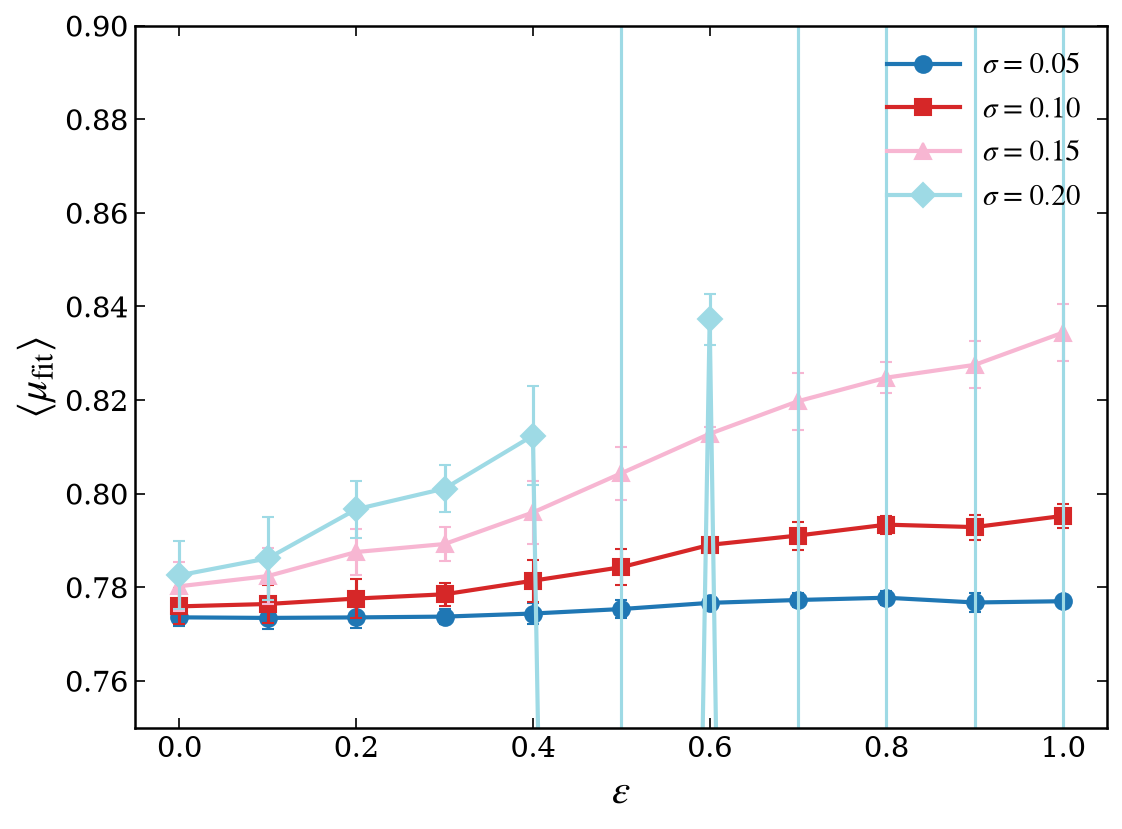

In [98]:
plot_metric_vs_eps(df, "mu_fit_mean", ylabel=r"$\langle \mu_{\rm fit} \rangle$", 
                   ymin=0.75, ymax=0.9, title="")


#### `sigma_fit`

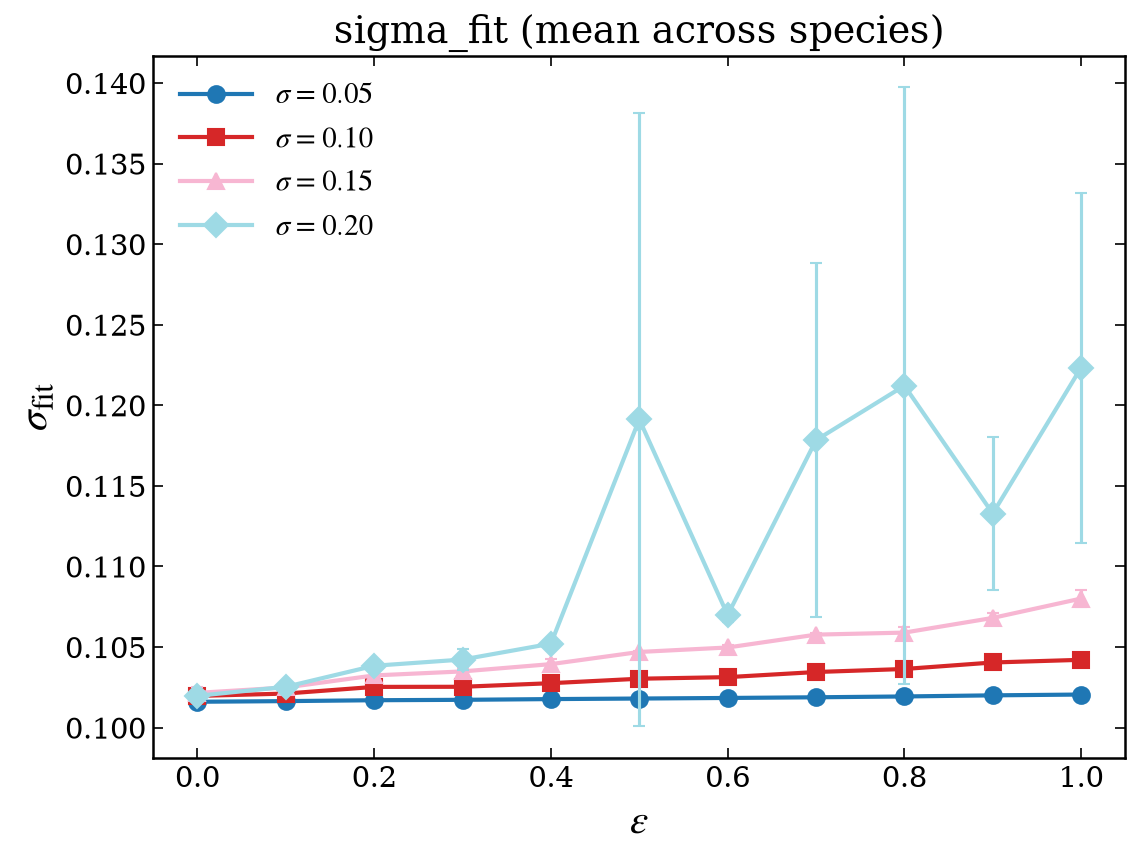

In [99]:
plot_metric_vs_eps(df, "sigma_fit_mean", ylabel=r"$\sigma_{\rm fit}$", title="sigma_fit (mean across species)")


#### `amplitude_fit`

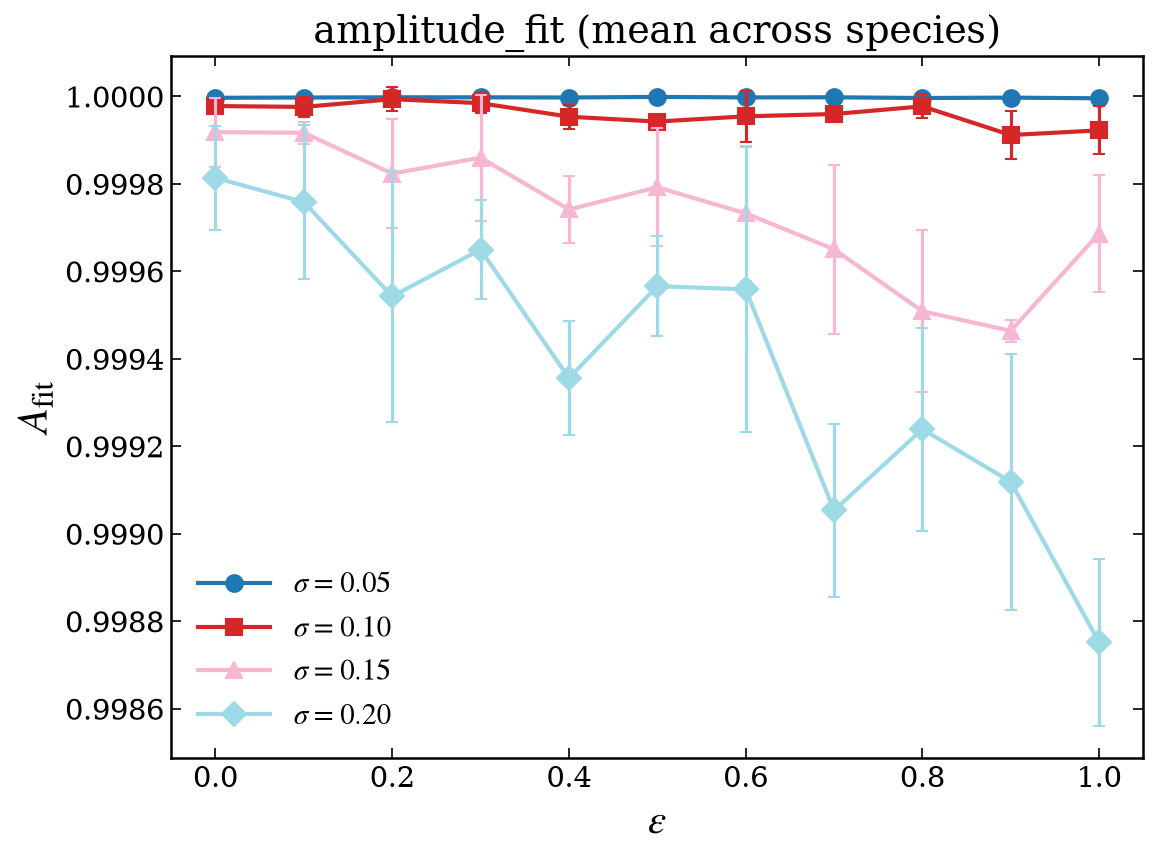

In [100]:
plot_metric_vs_eps(df, "amplitude_fit_mean", ylabel=r"$A_{\rm fit}$", title="amplitude_fit (mean across species)")


#### `mean_emp`

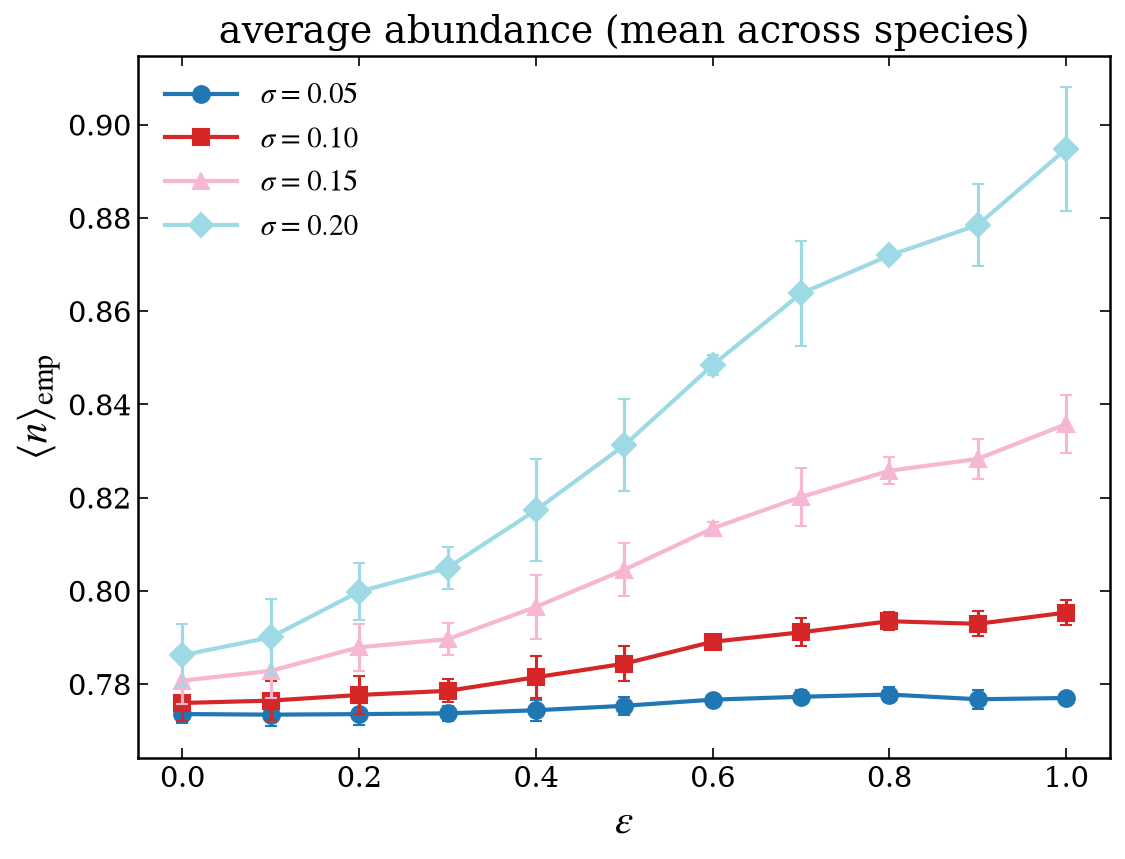

In [101]:
plot_metric_vs_eps(df, "mean_emp_mean", ylabel=r"$\langle n \rangle_{\rm emp}$", title="average abundance (mean across species)")


#### `error_fit`

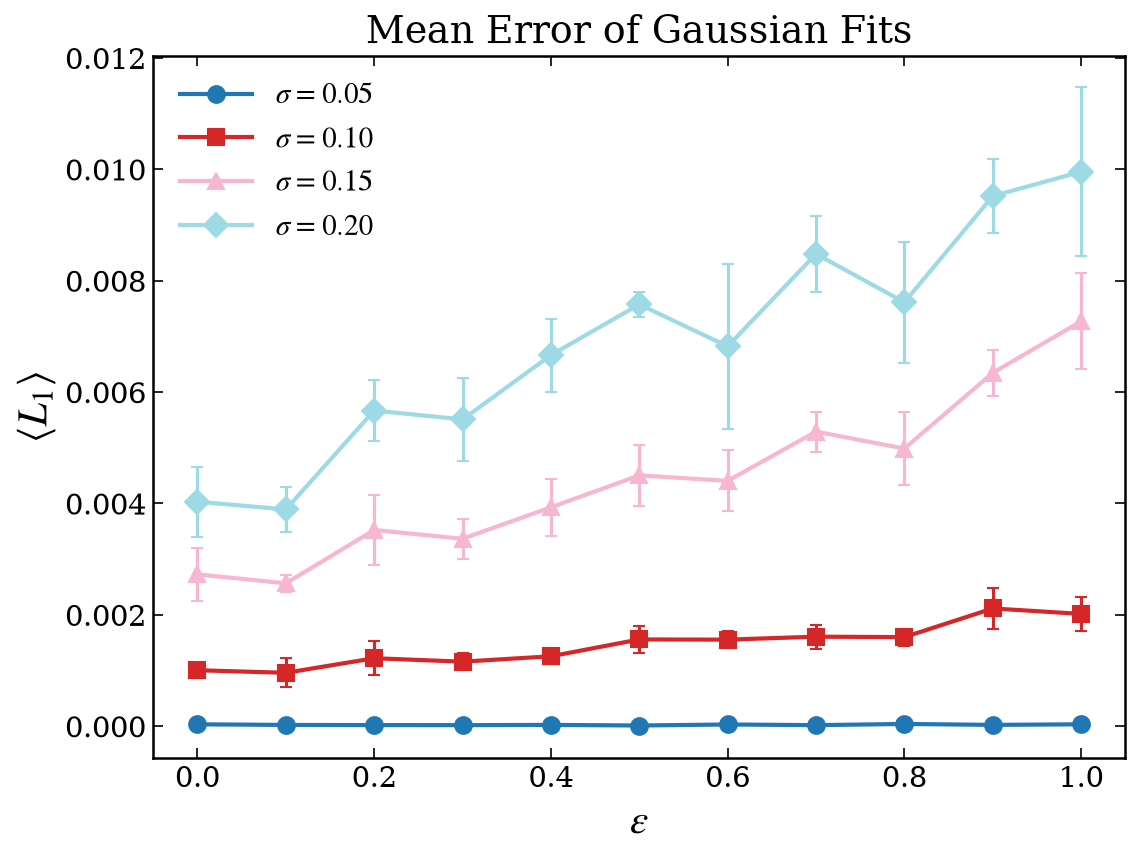

In [102]:
plot_metric_vs_eps(df, "error_fit_mean", ylabel=r"$\langle L_1 \rangle$", 
                   title="Mean Error of Gaussian Fits")


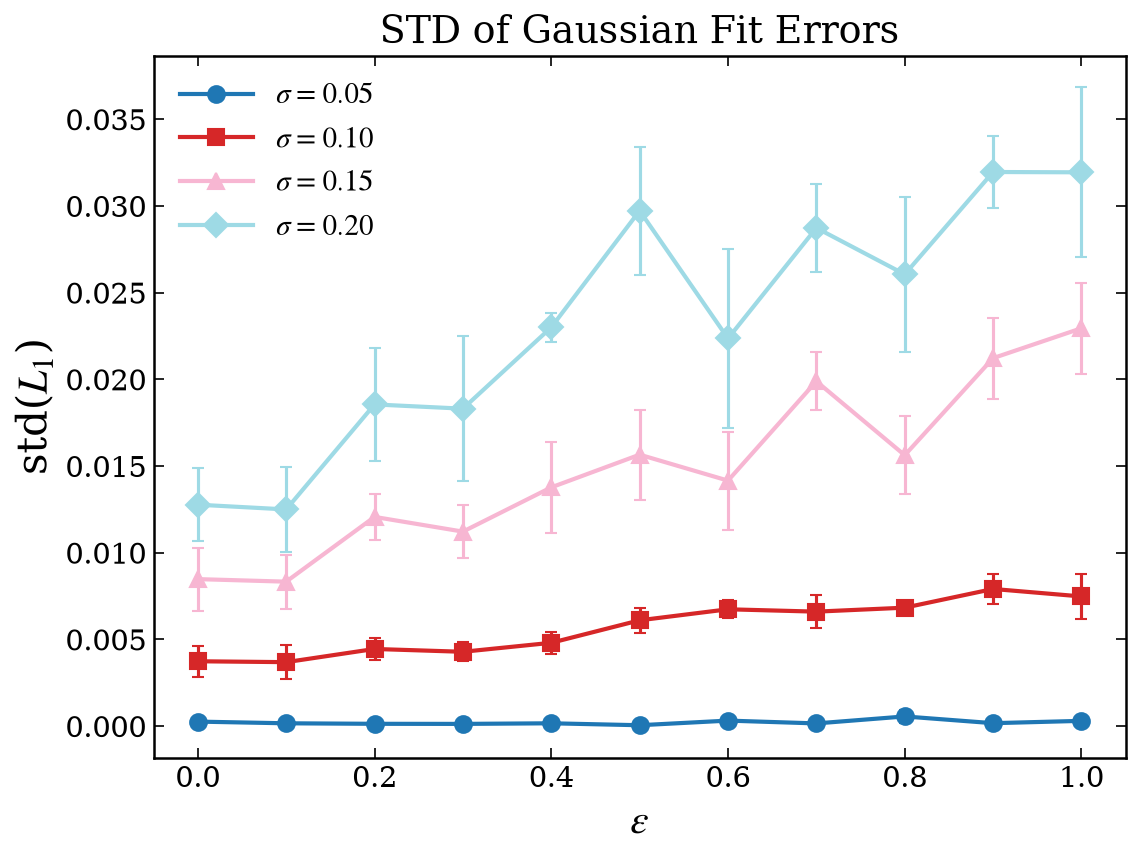

In [103]:
plot_metric_vs_eps(df, "error_fit_std", ylabel=r"std($L_1$)", title="STD of Gaussian Fit Errors")


#### `error_skewness`

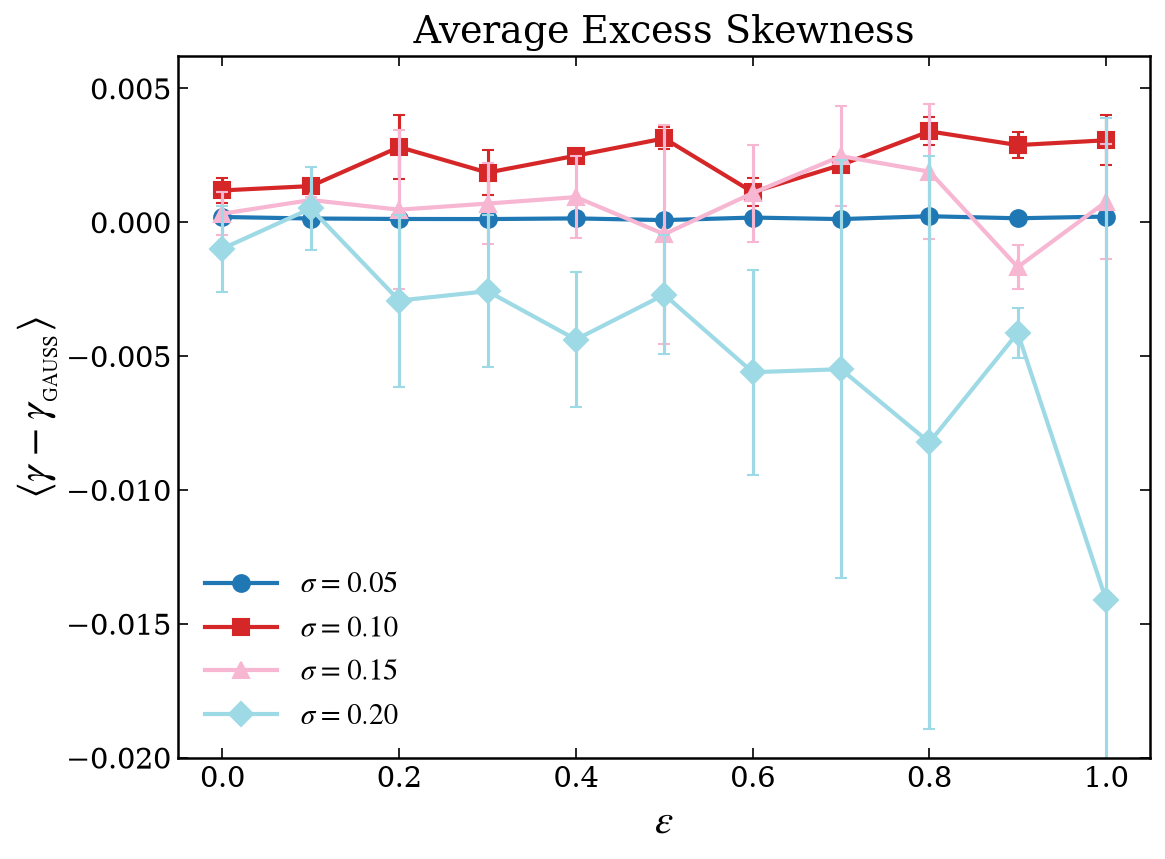

In [104]:
plot_metric_vs_eps(df, "error_skewness_mean", 
                   ylabel=r"$\langle \gamma - \gamma_{\rm {}_{GAUSS}} \rangle$", title="Average Excess Skewness",
                   ymin=-0.02)


#### `error_kurtosis`

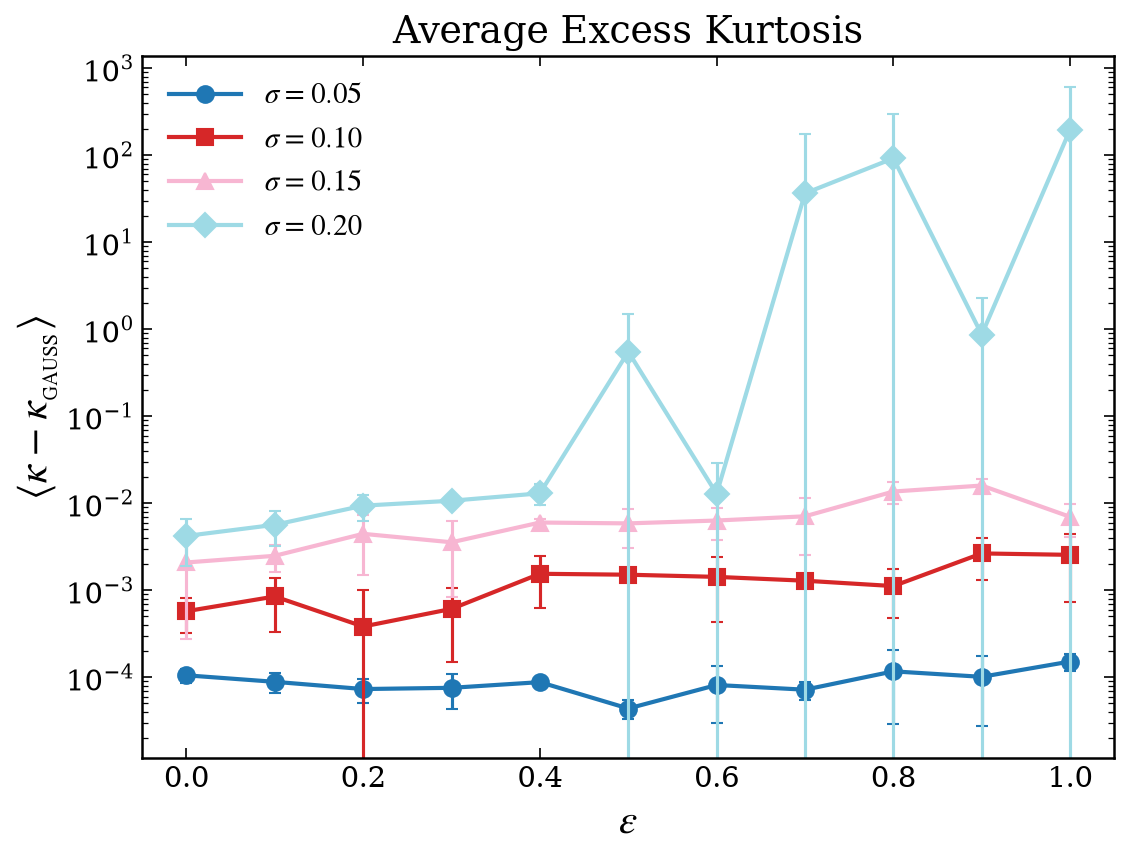

In [105]:
plot_metric_vs_eps(df, "error_kurtosis_mean", ylabel=r"$\langle \kappa - \kappa_{\rm {}_{GAUSS}} \rangle$", 
                   title="Average Excess Kurtosis", logscaley=True)


#### `js_divergence`

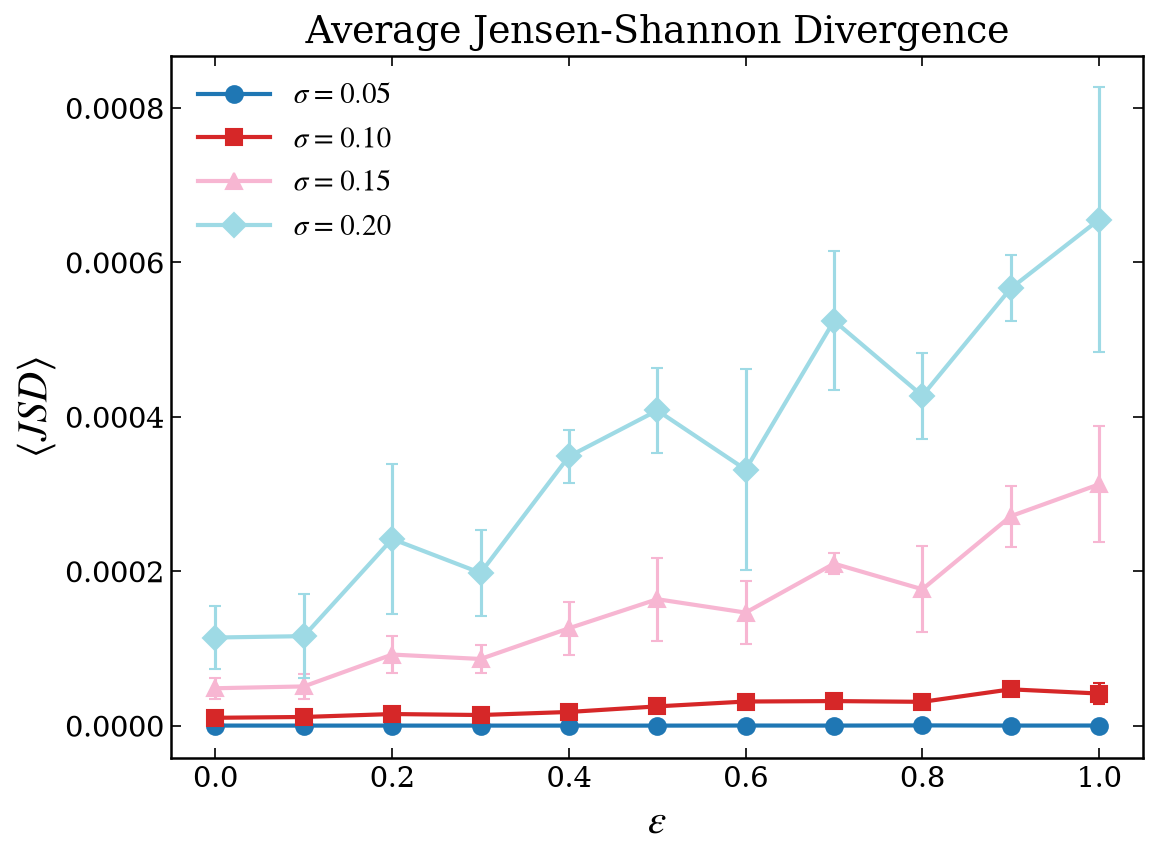

In [106]:
plot_metric_vs_eps(df, "js_divergence_mean", ylabel=r"$\langle JSD \rangle$", title="Average Jensen-Shannon Divergence")


#### `ks_stat`

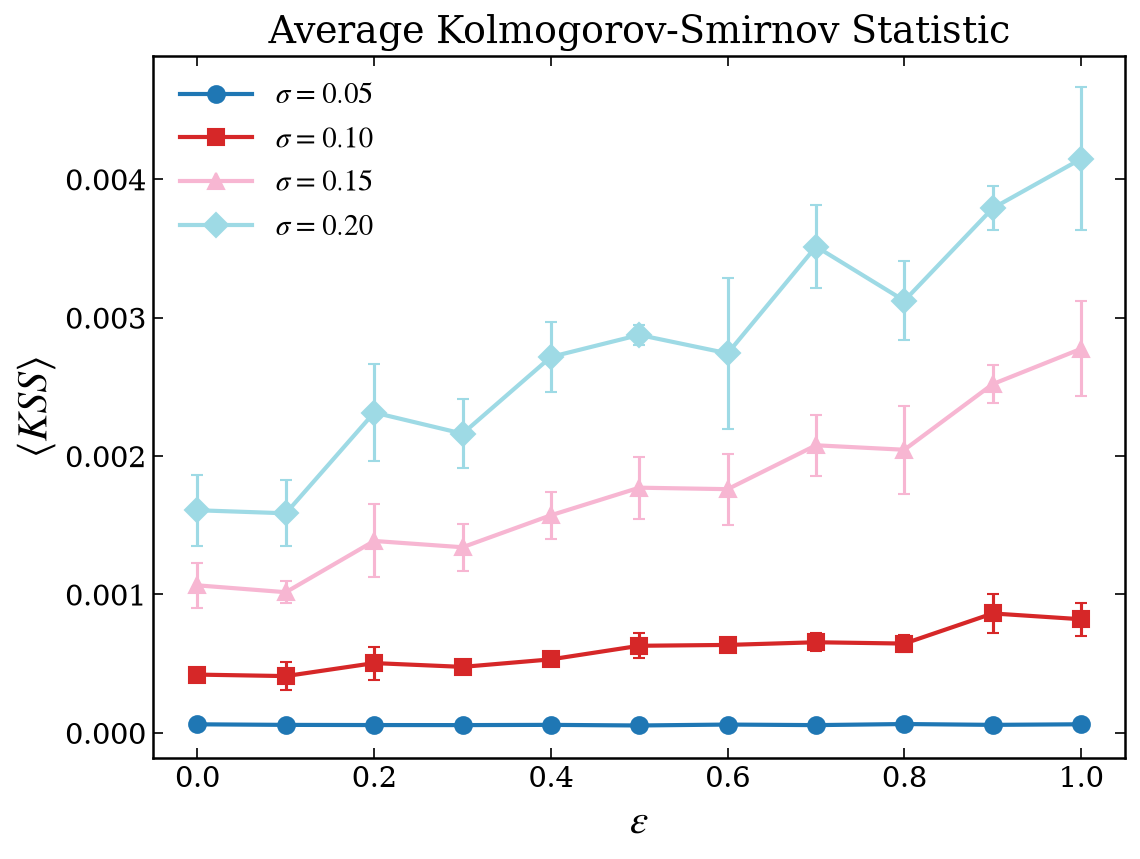

In [107]:
plot_metric_vs_eps(df, "ks_stat_mean", ylabel=r"$\langle KSS \rangle $", title="Average Kolmogorov-Smirnov Statistic")


#### `log_quadratic_r2`

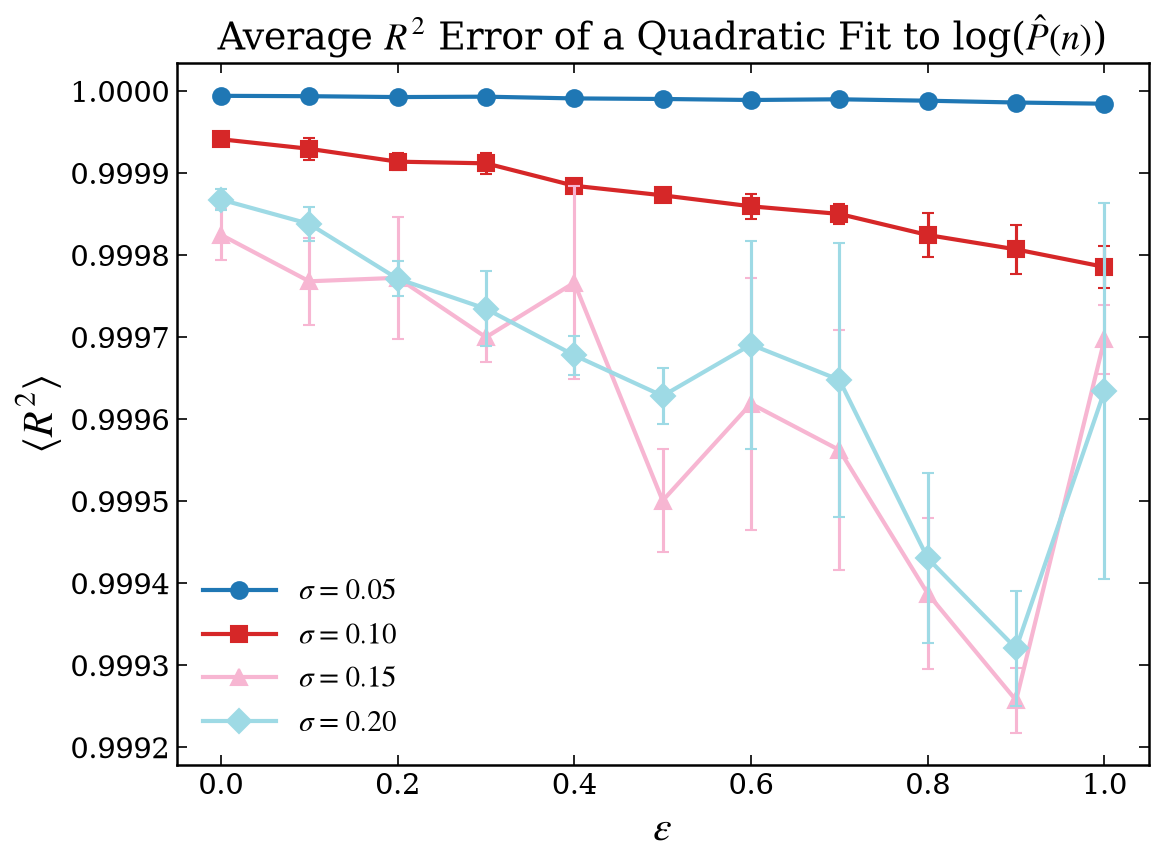

In [108]:
plot_metric_vs_eps(df, "log_quadratic_r2_mean", ylabel=r"$\langle R^2 \rangle$", title=r"Average $R^{2}$ Error of a Quadratic Fit to log($ \hat{P}(n)$)")


### Fit to the species-averaged distribution (`avgdist_*`)

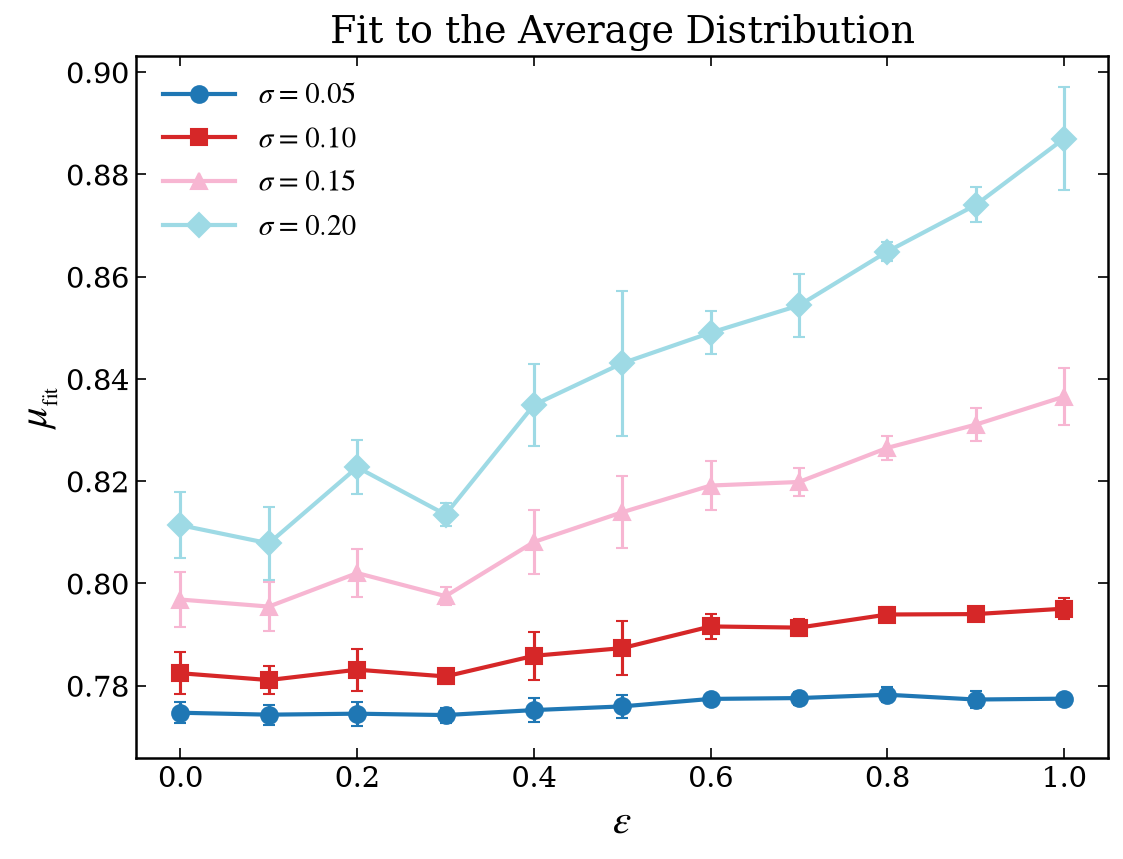

In [109]:
plot_metric_vs_eps(df, "avgdist_mu_fit", ylabel=r"$\mu_{\rm {}_{fit}}$", 
                   title="Fit to the Average Distribution")


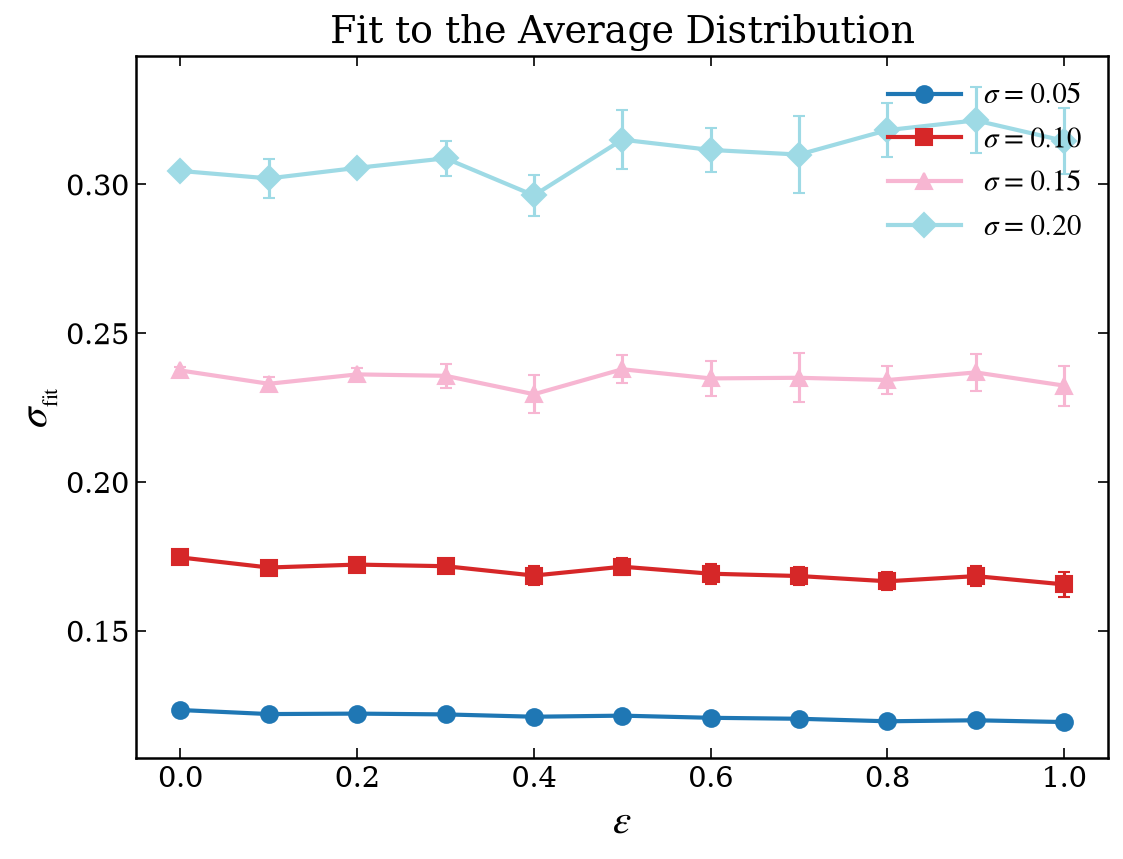

In [110]:
plot_metric_vs_eps(df, "avgdist_sigma_fit", ylabel=r"$\sigma_{\rm {}_{fit}}$", 
                   title="Fit to the Average Distribution")


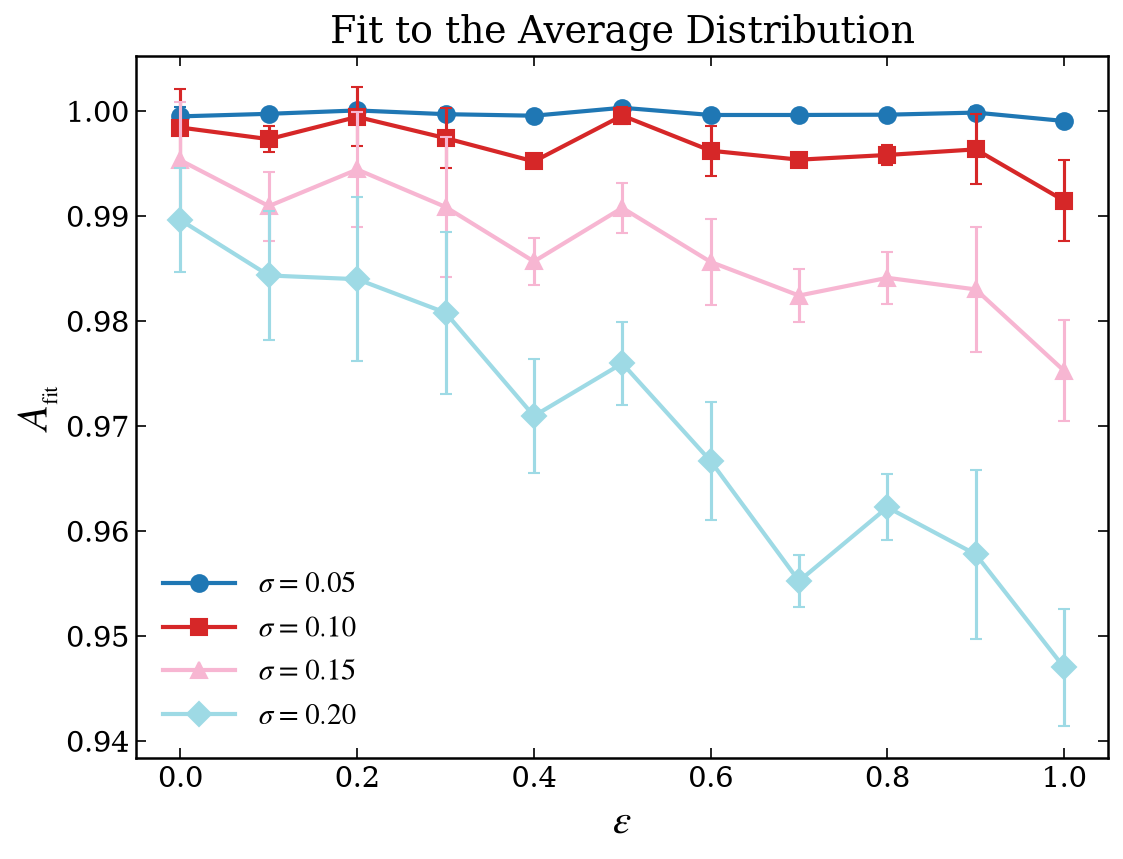

In [111]:
plot_metric_vs_eps(df, "avgdist_amplitude_fit", ylabel=r"$A_{\rm {}_{fit}}$", 
                   title="Fit to the Average Distribution")


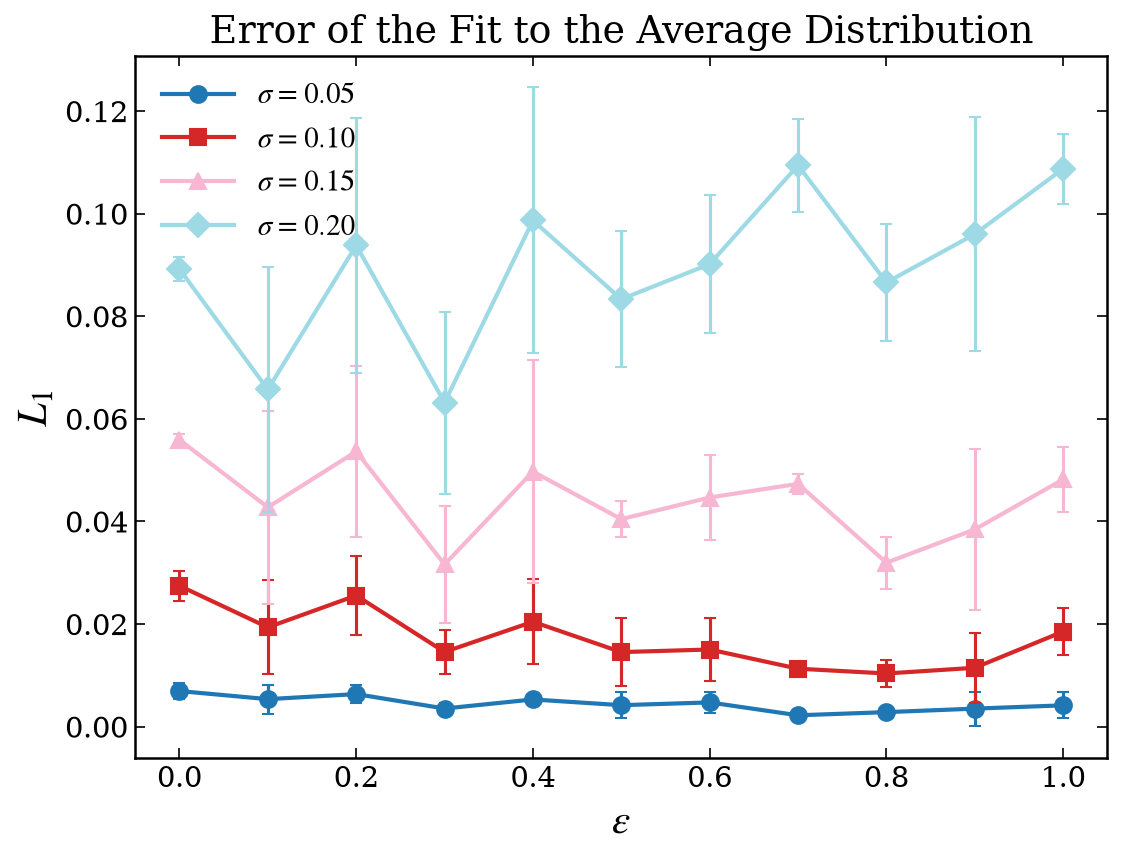

In [112]:
plot_metric_vs_eps(df, "avgdist_error_fit", ylabel=r"$L_1$", title="Error of the Fit to the Average Distribution")


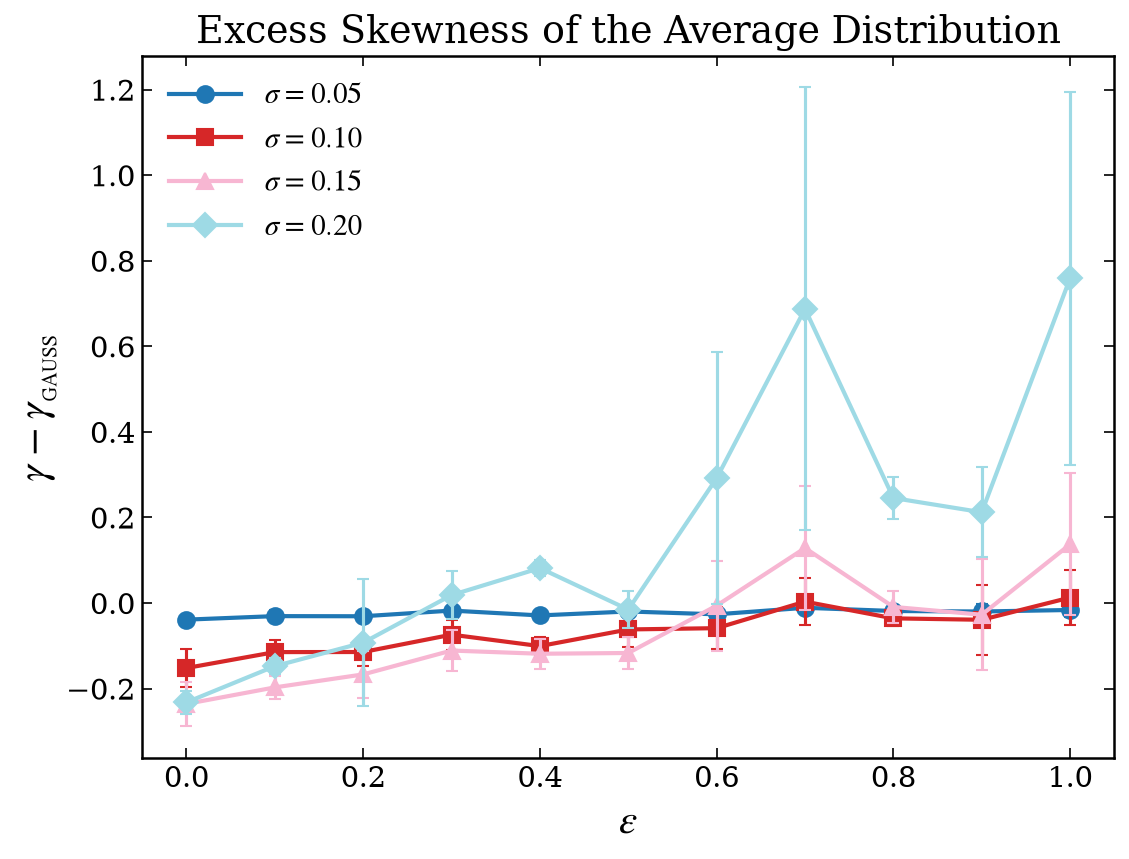

In [113]:
plot_metric_vs_eps(df, "avgdist_error_skewness", ylabel=r"$\gamma - \gamma_{\rm {}_{GAUSS}}$", 
                   title="Excess Skewness of the Average Distribution")


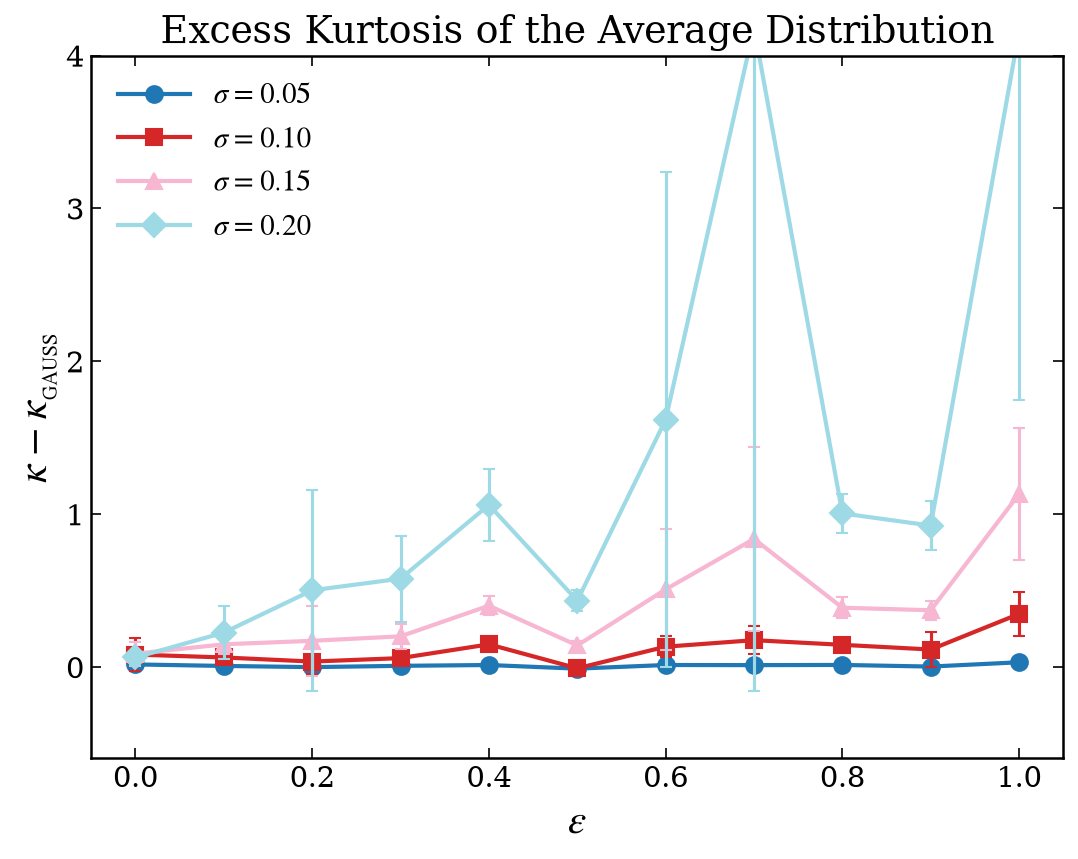

In [114]:
plot_metric_vs_eps(df, "avgdist_error_kurtosis", ylabel=r"$\kappa - \kappa_{\rm {}_{GAUSS}}$", 
                   title="Excess Kurtosis of the Average Distribution",
                   logscaley=False, ymax=4)


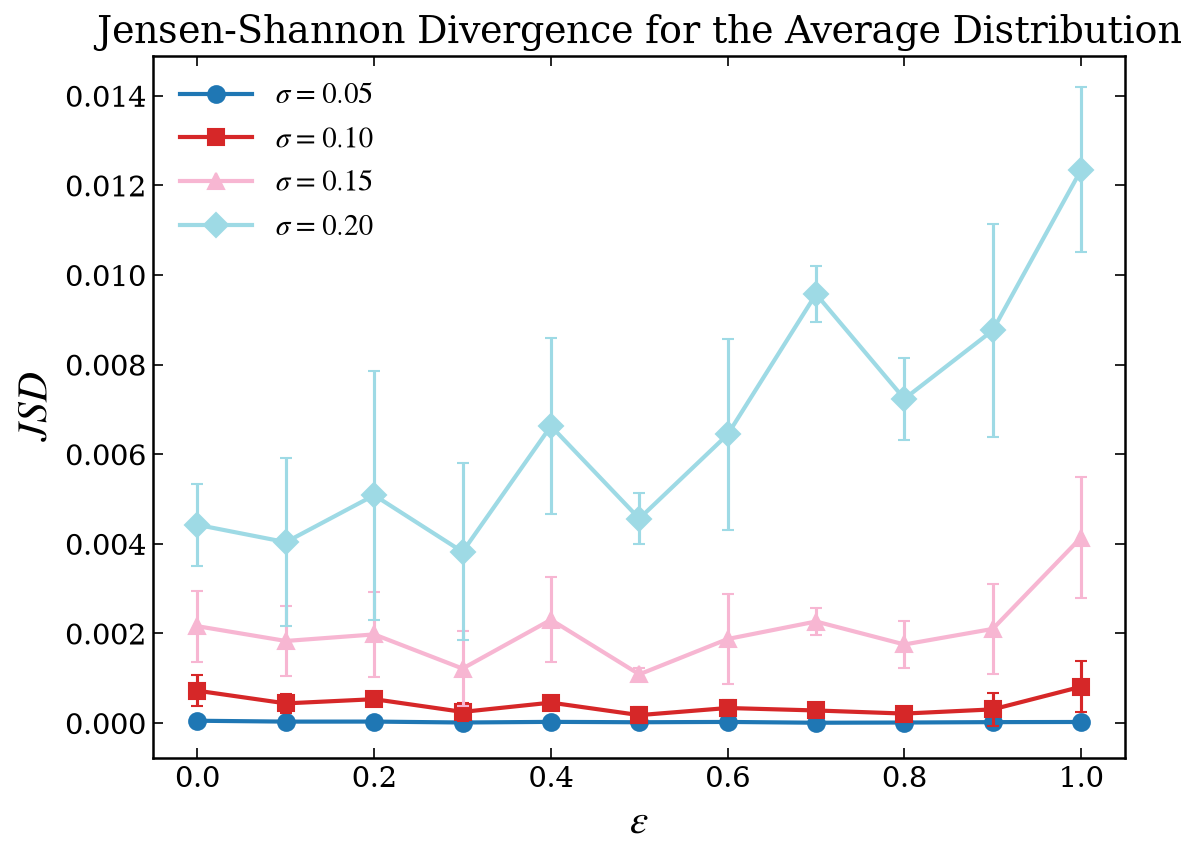

In [115]:
plot_metric_vs_eps(df, "avgdist_js_divergence", ylabel=r"$JSD$", title="Jensen-Shannon Divergence for the Average Distribution")


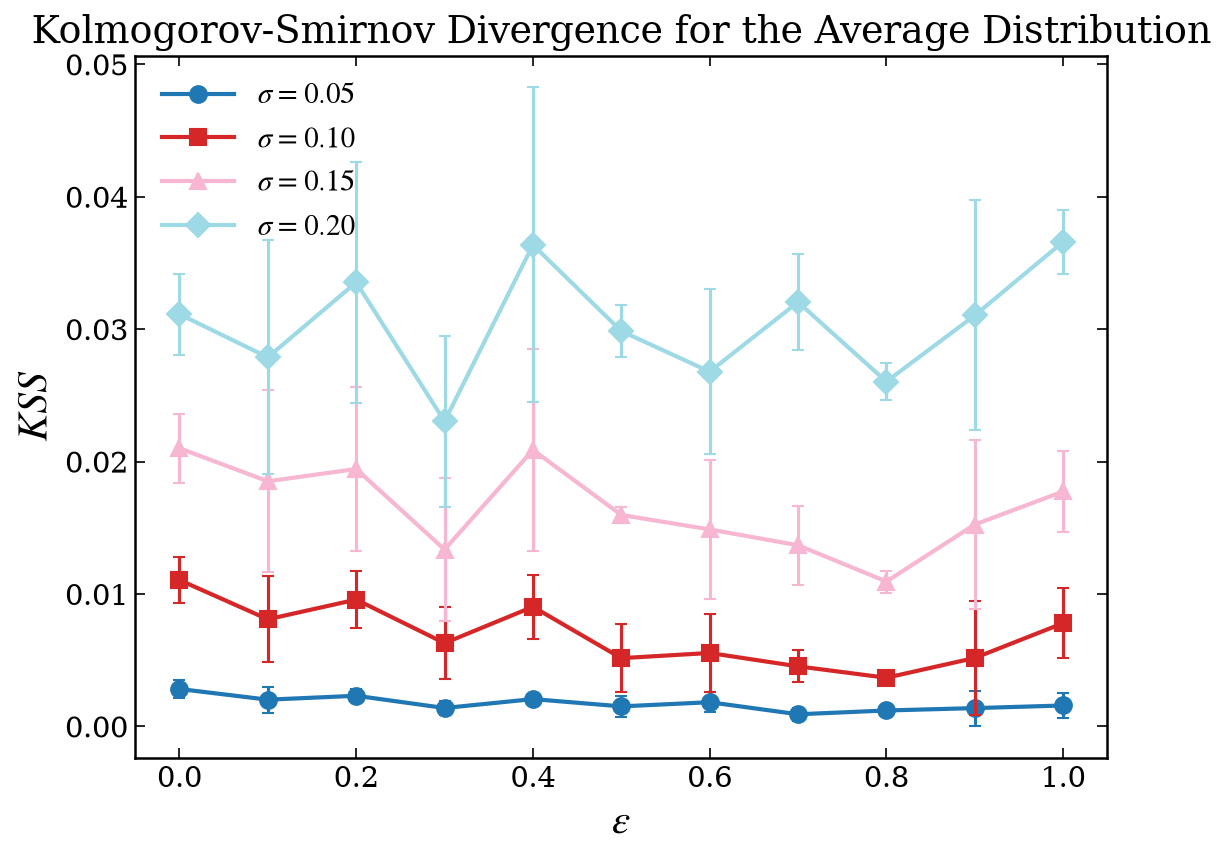

In [116]:
plot_metric_vs_eps(df, "avgdist_ks_stat", ylabel=r"$KSS$", title="Kolmogorov-Smirnov Divergence for the Average Distribution")


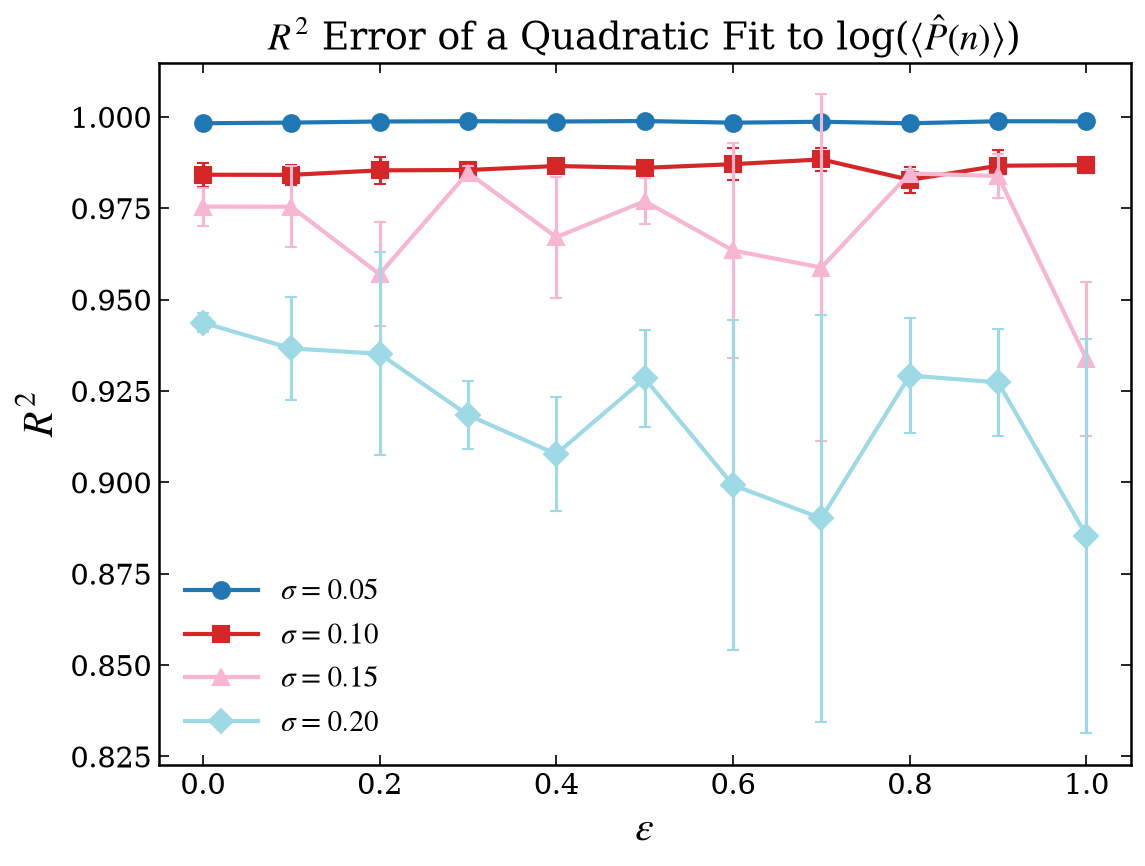

In [117]:
plot_metric_vs_eps(df, "avgdist_log_quadratic_r2", ylabel=r"$R^2$", title=r"$R^{2}$ Error of a Quadratic Fit to log($ \langle \hat{P}(n) \rangle$)")


## 2. Species-averaged distribution $P(n)$ vs. $n$, curves for each $\epsilon$

One figure per $\sigma$; `sgraph` and `seedinit` select which replicate's average distribution is shown (change them below and re-run).

In [118]:
def find_all_avg_dist_files(dist_dir, eps, sigma, tol=1e-6):
    """Locate every *_avg_dist_fit.txt file matching (eps, sigma), across all the
    sgraph and seedinit replicates present in dist_dir.

    eps/sigma are matched numerically (via parse_filename) since their string
    formatting in the filename isn't assumed.
    """
    pattern = os.path.join(dist_dir, f"PBMF_gr_in_RRG_*{AVG_DIST_SUFFIX}")
    matches = []
    for path in sorted(glob.glob(pattern)):
        reconstructed = os.path.basename(path)[:-len(AVG_DIST_SUFFIX)] + ".txt"
        params = parse_filename(reconstructed)
        if params is None:
            continue
        if np.isclose(params['eps'], eps, atol=tol) and np.isclose(params['sigma'], sigma, atol=tol):
            matches.append(path)
    return matches


def load_pooled_distribution(dist_dir, eps, sigma, column=1, tol=1e-6):
    """Average column `column` (P_avg=1, Phat_avg=2, ...) of the avg_dist_fit files
    pointwise over every (sgraph, seedinit) replicate found for (eps, sigma).

    Each replicate curve is already an average over the N=1024 species of that
    replicate; since every replicate has the same N, the pointwise mean over
    replicates equals the pooled average over all species x replicates combined.
    Replicates share the same grid start/step but can have different lengths (the
    solver only extends the grid as far as it needs), so shorter replicates are
    zero-padded up to the longest grid before averaging -- this pools away the
    bumpy tails caused by the few species with very large abundances in any single
    replicate, since a species reaching a given large n in only one replicate gets
    diluted by the (zero) contribution of the other replicates at that n.
    """
    paths = find_all_avg_dist_files(dist_dir, eps, sigma, tol=tol)
    if not paths:
        return None, None, 0

    curves = [np.loadtxt(path, skiprows=1)[:, [0, column]] for path in paths]
    n_ref = max((c[:, 0] for c in curves), key=len)
    stacked = np.zeros((len(curves), len(n_ref)))
    for i, c in enumerate(curves):
        stacked[i, :len(c)] = c[:, 1]
    pooled = stacked.mean(axis=0)
    return n_ref, pooled, len(paths)


In [119]:
def plot_avg_P_vs_eps(df, dist_dir, sigma, eps_values=None,
                       figsize=(8, 6), dpi=150, legend_loc='best', legend_fontsize=14,
                       title_fontsize=18, label_fontsize=20, tick_fontsize=14,
                       linewidth=2, logscaley=True, xmin=None, xmax=None, ymin=None, ymax=None,
                       ax=None, save_to=None, column=1,
                       ylabel=r"$P(n)$"):
    """Plot P(n) (or Phat(n) with column=2) vs n, one curve per eps, for fixed sigma.

    Each curve is pooled over every (sgraph, seedinit) replicate found for that
    (eps, sigma) in dist_dir (see load_pooled_distribution).
    """
    plt.rcParams.update({
        "font.family": "serif",
        "mathtext.fontset": "stix",
        "axes.linewidth": 1.2,
    })
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
        fig.subplots_adjust(left=0.17, bottom=0.14, right=0.98, top=0.92)
    else:
        fig = ax.figure

    if eps_values is None:
        eps_values = sorted(df.loc[np.isclose(df['sigma'], sigma), 'eps'].unique())
    color_cycle = plt.cm.tab20(np.linspace(0, 1, max(len(eps_values), 1)))

    n_replicates = None
    for idx, eps in enumerate(eps_values):
        n, P_avg, n_found = load_pooled_distribution(dist_dir, eps, sigma, column=column)
        if n is None:
            print(f"  [warn] no avg-dist files for eps={eps}, sigma={sigma}")
            continue
        n_replicates = n_found
        color = color_cycle[idx % len(color_cycle)]
        ax.plot(n, P_avg, linestyle='-', linewidth=linewidth, color=color,
                label=fr'$\epsilon={eps:.2f}$')

    if logscaley:
        ax.set_yscale('log')
    if xmin is not None:
        ax.set_xlim(left=xmin)
    if xmax is not None:
        ax.set_xlim(right=xmax)
    if ymin is not None:
        ax.set_ylim(bottom=ymin)
    if ymax is not None:
        ax.set_ylim(top=ymax)
    ax.set_xlabel(r"$n$", fontsize=label_fontsize)
    ax.set_ylabel(ylabel, fontsize=label_fontsize)
    title = fr"$\sigma={sigma:.2f}$"
    if n_replicates is not None:
        title += f" (pooled over {n_replicates} graph/seed replicates)"
    ax.set_title(title, fontsize=title_fontsize)
    ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
                   labelsize=tick_fontsize, length=3)
    ax.tick_params(axis='both', which='major', direction='in', top=True, right=True,
                   labelsize=tick_fontsize, length=5)
    if logscaley:
        ax.yaxis.set_major_formatter(LogFormatterMathtext())
    ax.legend(loc=legend_loc, fontsize=legend_fontsize, frameon=False, handlelength=2.5, ncol=2)

    if save_to is not None:
        fig.savefig(save_to)
    plt.show()


In [120]:
sigma_values = sorted(df['sigma'].unique())
print(f"Found sigma values: {sigma_values}")


Found sigma values: [np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2)]


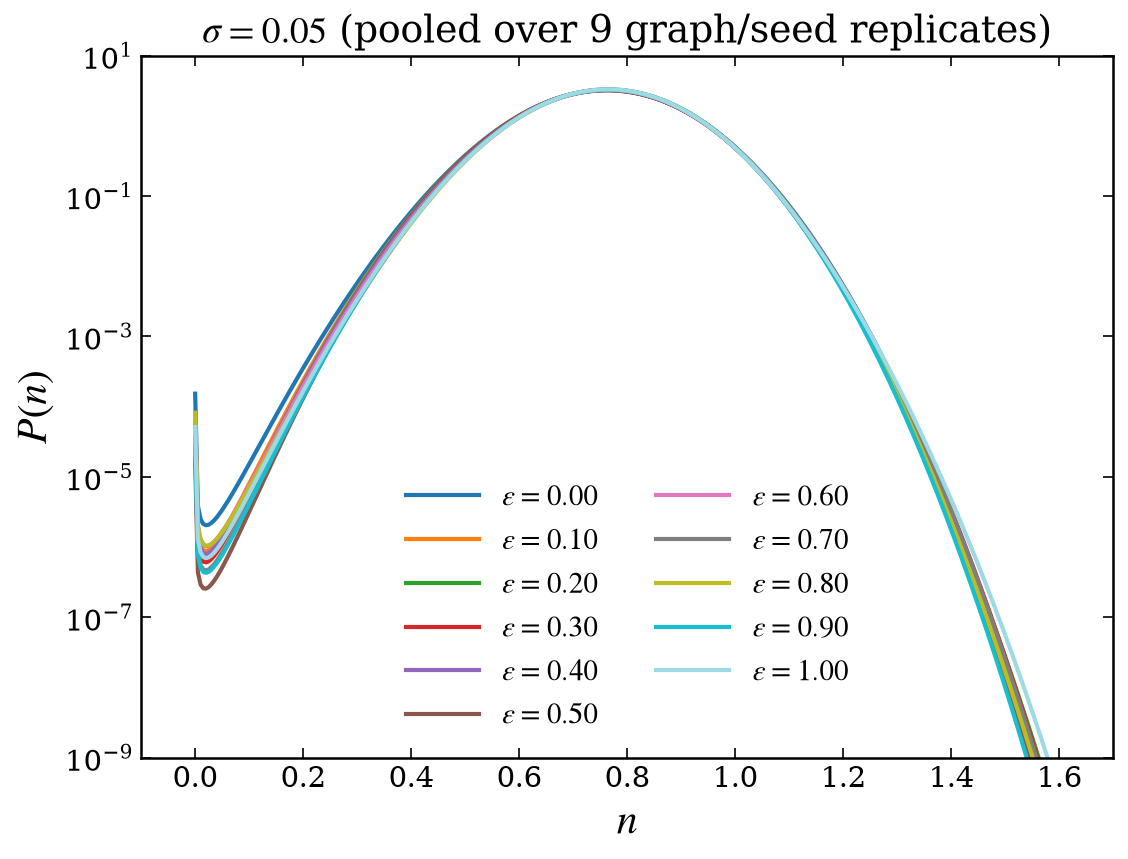

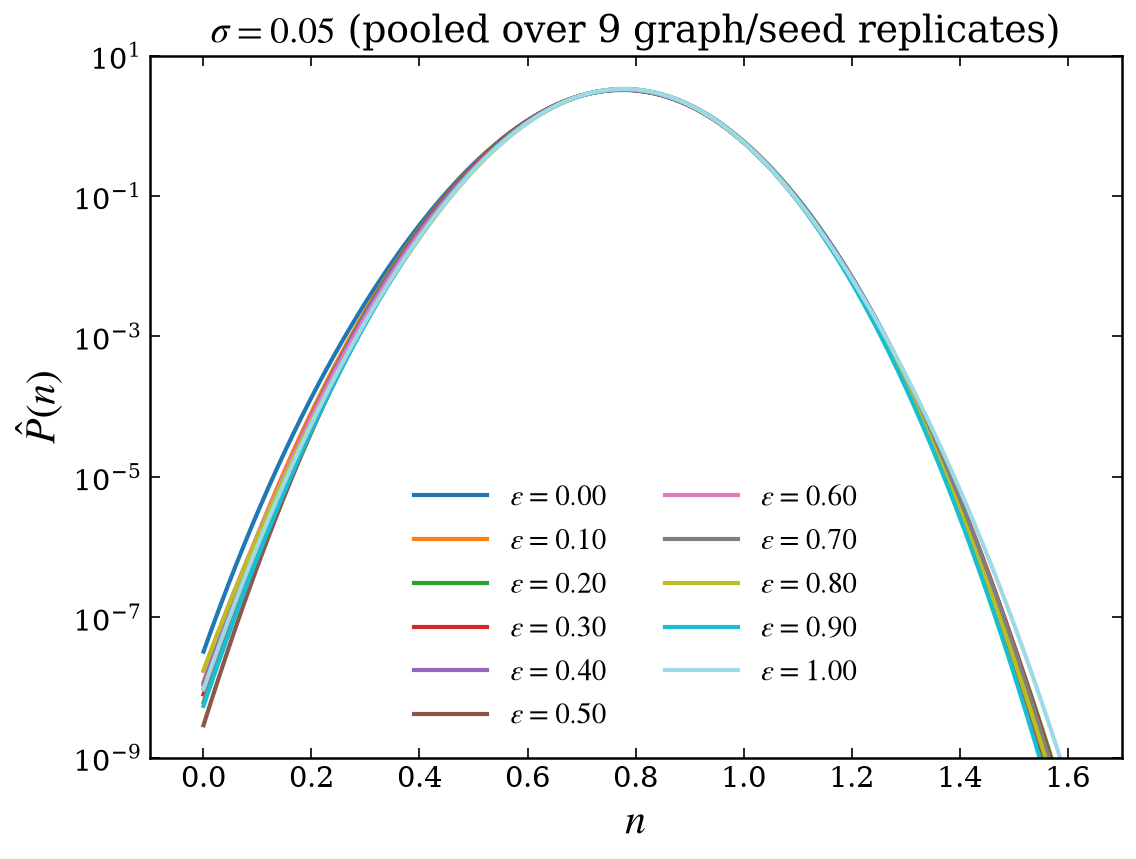

In [121]:
sigma = 0.05
plot_avg_P_vs_eps(df, DIST_DIR, sigma, column=1,
                  ymin=1e-9, ymax=10, xmax=1.7)
plot_avg_P_vs_eps(df, DIST_DIR, sigma, column=2,
                  ylabel=r"$\hat{P}(n)$", ymin=1e-9, ymax=10, xmax=1.7)


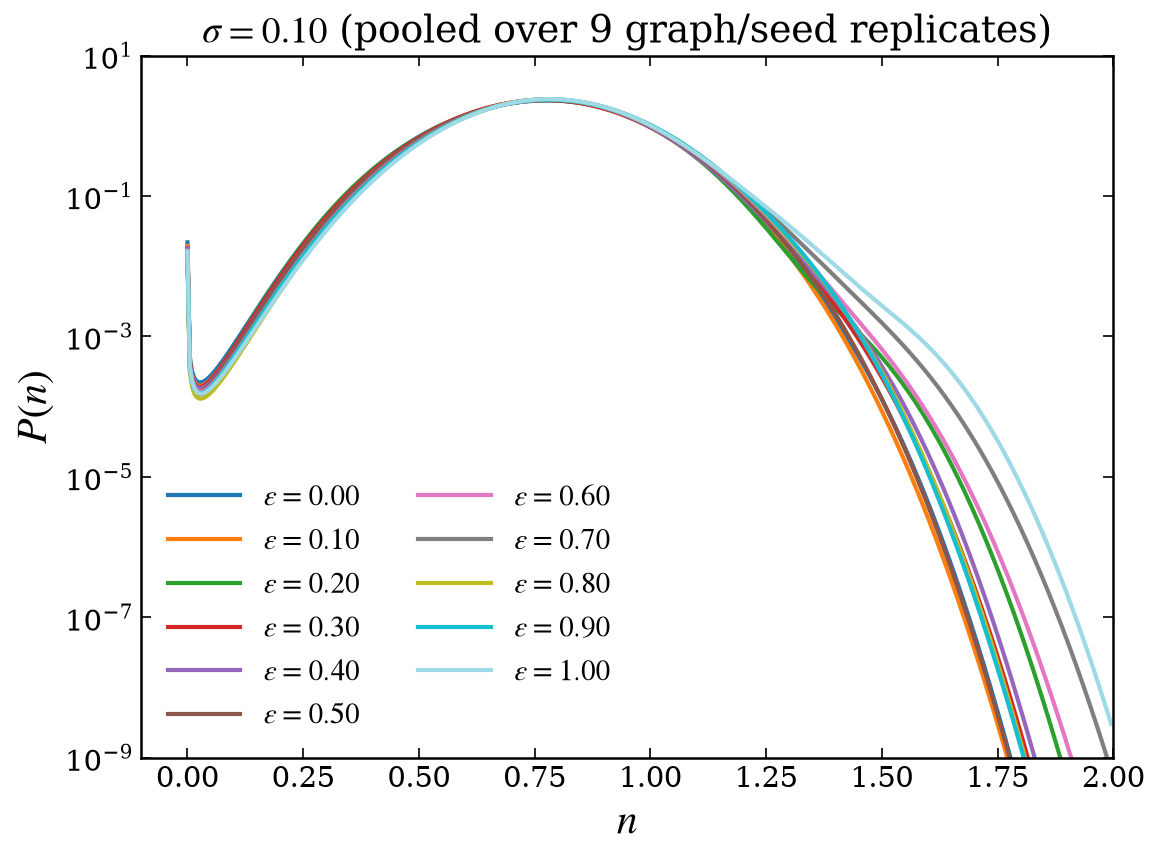

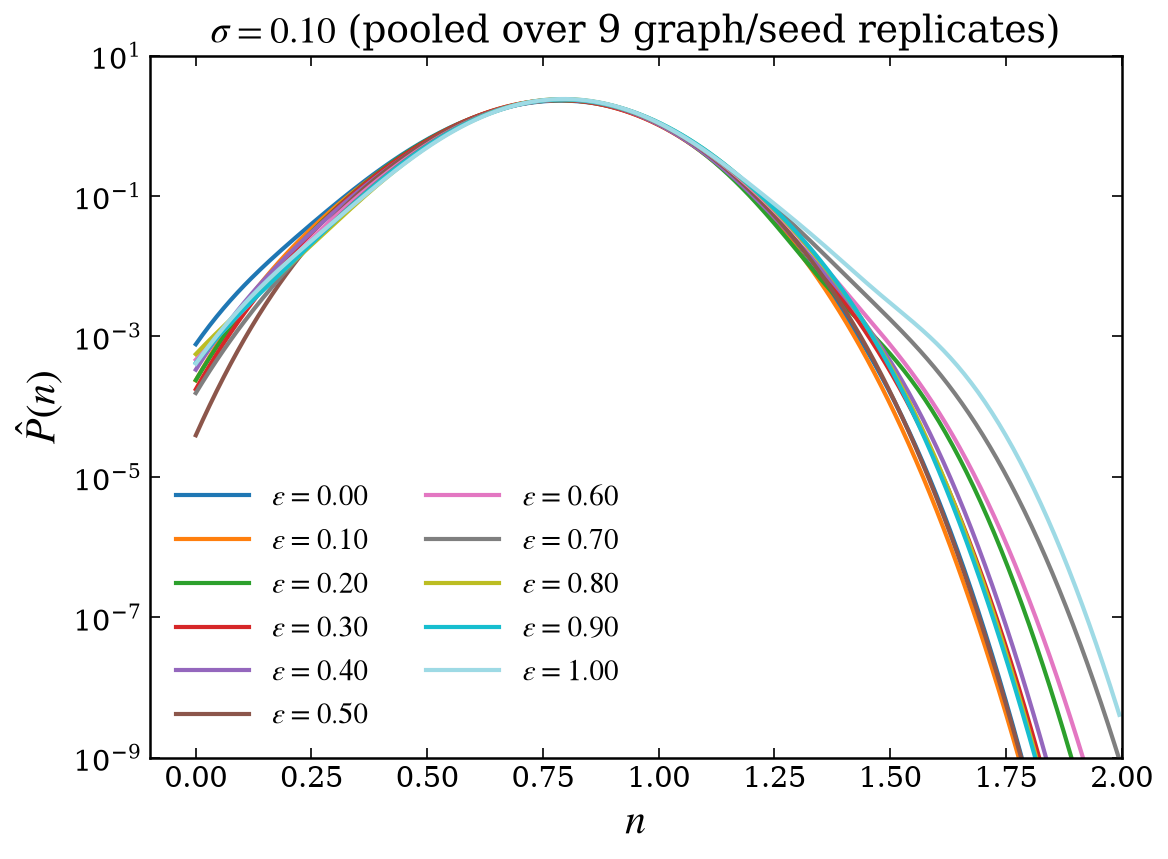

In [122]:
sigma = 0.10
plot_avg_P_vs_eps(df, DIST_DIR, sigma, column=1,
                  ymin=1e-9, ymax=10, xmax=2)
plot_avg_P_vs_eps(df, DIST_DIR, sigma, column=2,
                  ylabel=r"$\hat{P}(n)$", ymin=1e-9, ymax=10, xmax=2)


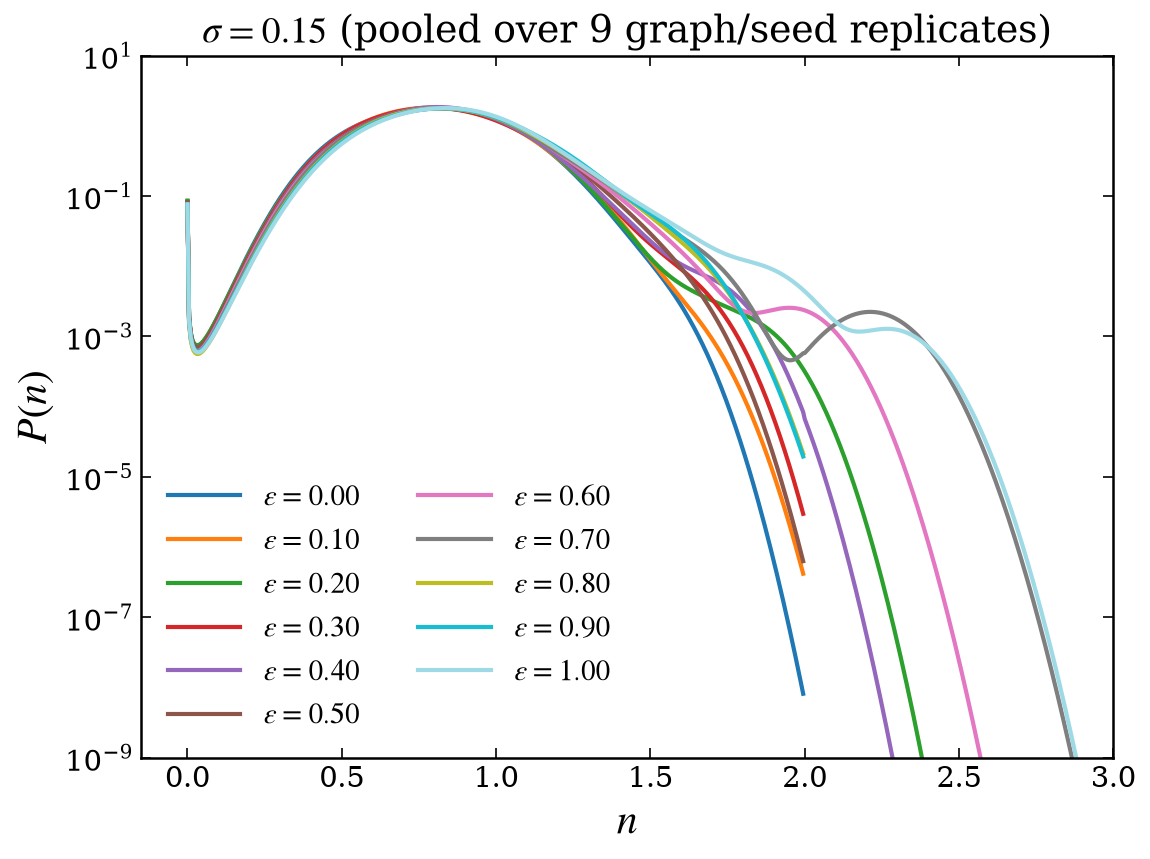

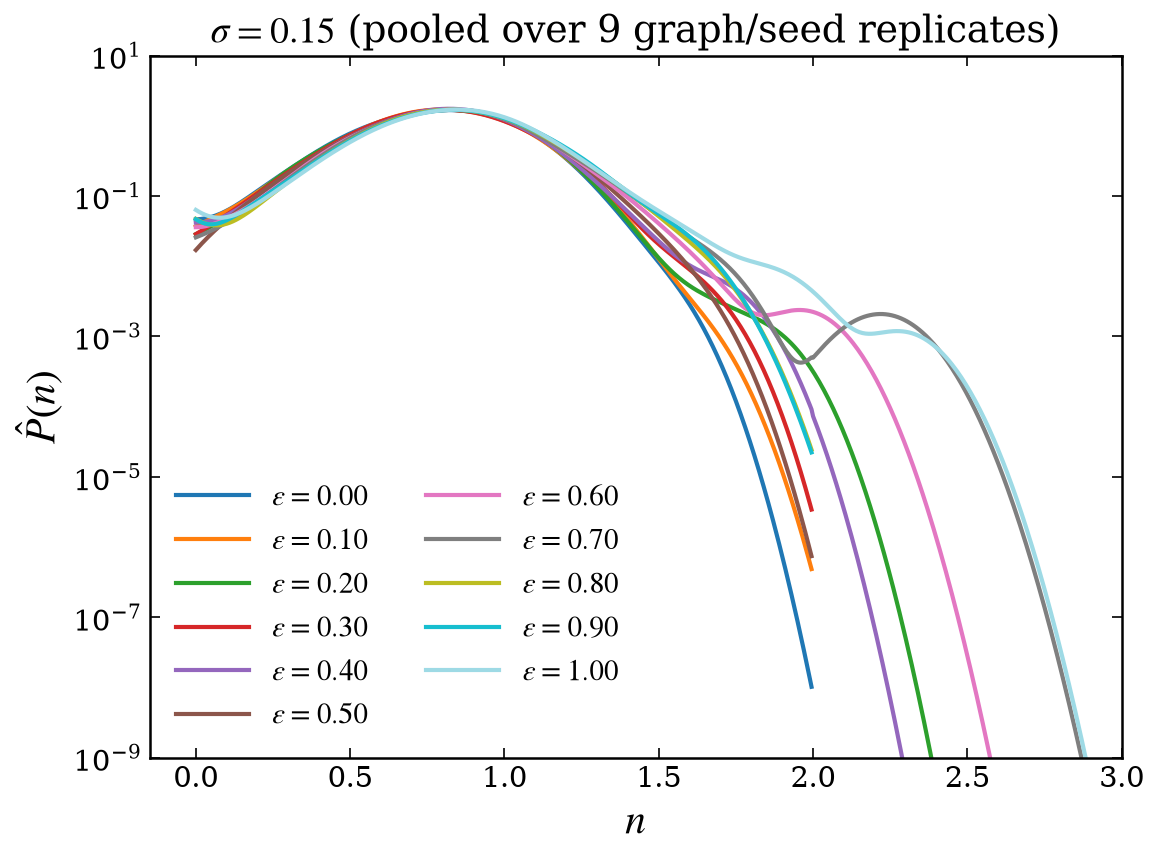

In [123]:
sigma = 0.15
plot_avg_P_vs_eps(df, DIST_DIR, sigma, column=1,
                  ymin=1e-9, ymax=10, xmax=3)
plot_avg_P_vs_eps(df, DIST_DIR, sigma, column=2,
                  ylabel=r"$\hat{P}(n)$", ymin=1e-9, ymax=10, xmax=3)


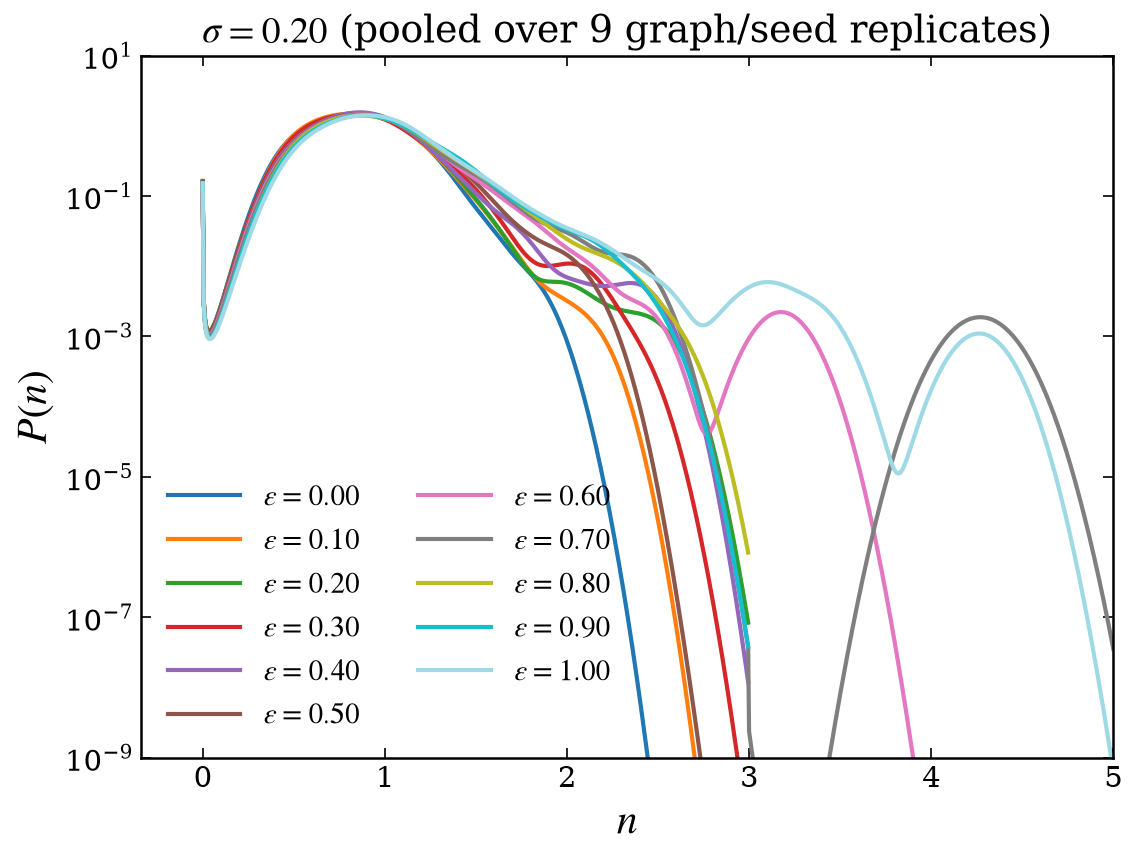

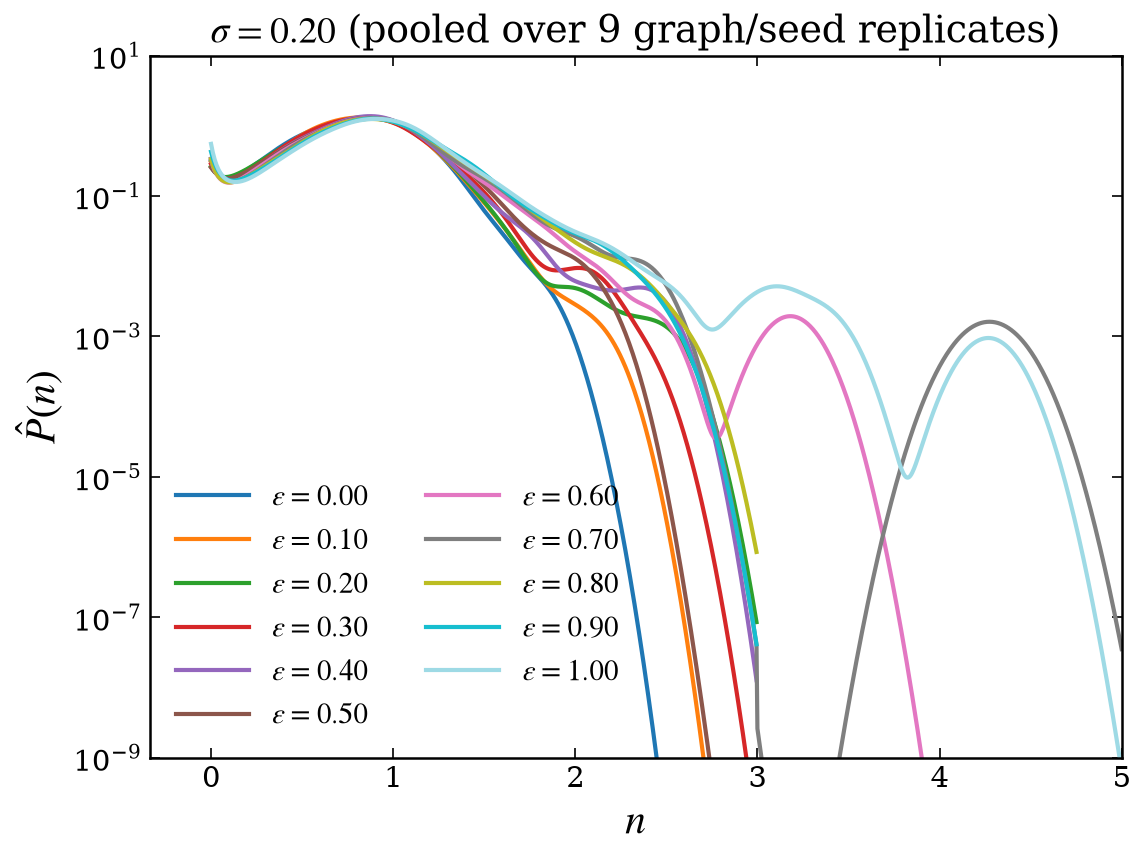

In [124]:
sigma = 0.20
plot_avg_P_vs_eps(df, DIST_DIR, sigma, column=1,
                  ymin=1e-9, ymax=10, xmax=5)
plot_avg_P_vs_eps(df, DIST_DIR, sigma, column=2,
                  ylabel=r"$\hat{P}(n)$", ymin=1e-9, ymax=10, xmax=5)
